# Librerías

In [ ]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
import Funciones as Funciones
from NNMF_GIF2 import NNMF_GIF
from pathlib import Path
%config InlineBackend.figure_format = 'svg'
from ipyfilechooser import FileChooser


# Definición de parámetros

In [ ]:
archivo = 'FN001_I_16'
# =========================================
norma ='frobenius'
pre_iteraciones = 0
iteraciones     = 250
p_filtro        = 14
alfa = 0.99
p = 0.55
pre_enfasis     = True
duracion        = 5.5
guardar_proceso = False
normalizar_espectrogramas = True

# =========================================
cmap = Funciones.parula_map
color_ACC = 'blue'
color_EGG = 'orange'
color_dEGG = 'g'
color_OVV = 'magenta'
color_speech = 'black'
legend_loc = 'upper right'

# Carga de la señal

In [50]:
print(archivo)

FN001_I_16.txt


In [56]:
ruta = Path('Señales AC3E') / 'Femenino' / f'{archivo}.txt'

datos = np.loadtxt(ruta, delimiter='\t', skiprows=1)


fs_r = 8000 
señal_MBK  = datos[:, 0]
#b,a = sig.butter(2, 50, 'hp', fs=fs_r)
#señal_MBK = sig.filtfilt(b,a,señal_MBK)

señal_ACC  = -datos[:, 1]

señal_EGG  = datos[:, 2]
maximo     = max(señal_EGG)
señal_EGG = [valor/maximo for valor in señal_EGG]
señal_dEGG = np.gradient(señal_EGG)
señal_OVV  = datos[:, 3]
maximo     = max(señal_dEGG)
señal_dEGG = [valor/maximo for valor in señal_dEGG]

to = 0
tf = 50

tiempos       = np.arange(to,tf,1000/fs_r)

FileNotFoundError: Señales AC3E\Femenino\FN001_I_16.txt.txt not found.

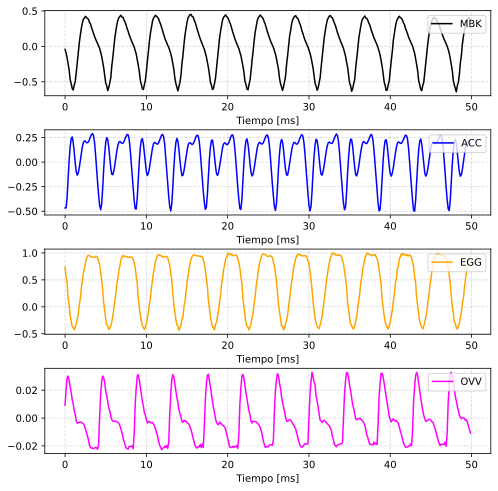

In [53]:
fig,ax = plt.subplots(4,1,figsize=(8,8))
plt.subplots_adjust(hspace=0.4)
ax[0].plot(tiempos,señal_MBK,color=color_speech,label='MBK')
ax[1].plot(tiempos,señal_ACC,color=color_ACC,label='ACC')
ax[2].plot(tiempos,señal_EGG,color=color_EGG,label='EGG')
ax[3].plot(tiempos,señal_OVV,color=color_OVV,label='OVV')

for ax_ in ax:
    ax_.legend(loc=legend_loc)
    ax_.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
    ax_.set_xlabel('Tiempo [ms]') 

# Plot

In [54]:
SP= NNMF_GIF(speech=señal_MBK,
              acelerometro=señal_ACC,
              tiempos=tiempos,fs=fs_r,
               norma=norma,
               pre_iteraciones=pre_iteraciones,
               iteraciones=iteraciones,
               p_filtro=p_filtro,
               alfa=alfa,
               p=0.55,
               pre_enfasis=pre_enfasis,
               duracion=duracion,
               guardar_proceso=guardar_proceso,
               normalizar_espectrogramas = normalizar_espectrogramas)

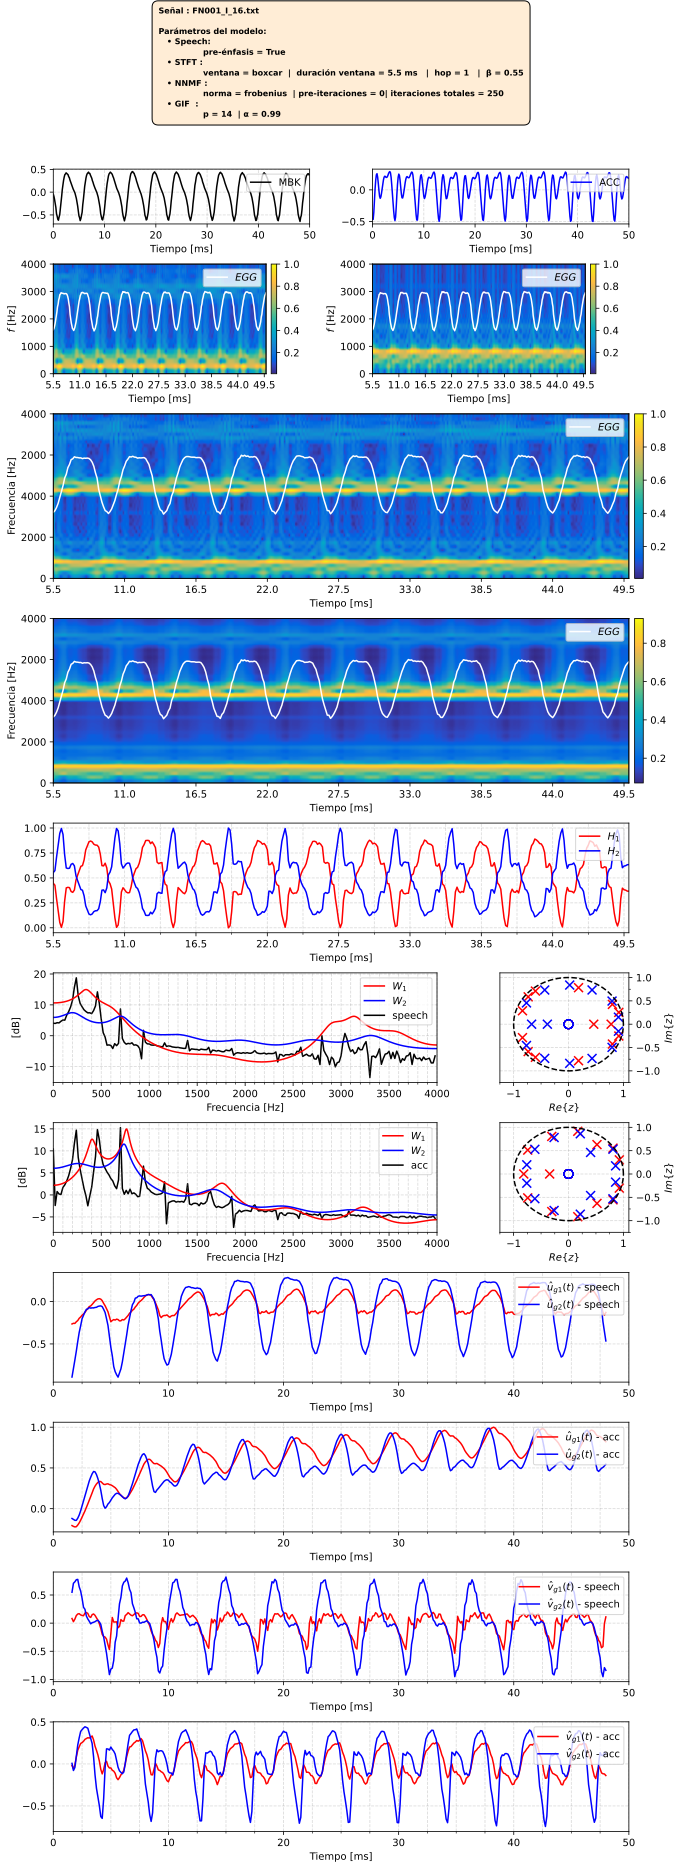

In [55]:
fig = plt.figure(figsize=(8,30))

color1 = 'red'
color2 = 'blue'
color3 = 'k'
loc  = 'upper right' 
line_width = 1.5
widths  = [1,0.5,0.5,1]
heights = [0.5,1,1.5,1.5,1,1,1,1,1,1,1]
gs  = fig.add_gridspec(11, 4,width_ratios=widths,height_ratios=heights,left=0,right=1,wspace=0.65,hspace=0.35)
# Señales temporales
ax0 = fig.add_subplot(gs[0,0:2])
ax1 = fig.add_subplot(gs[0,2:])

# Espectrogramas
ax2 = fig.add_subplot(gs[1,0:2])
ax3 = fig.add_subplot(gs[1,2:])

# Espectrograma
ax4 = fig.add_subplot(gs[2,:])

# Espectrograma aproximado
ax5 = fig.add_subplot(gs[3,:])

# Activacion
ax6 = fig.add_subplot(gs[4,:])

# Resp frecuencia y polos y ceros
ax7 = fig.add_subplot(gs[5,:3])
ax8 = fig.add_subplot(gs[5,3])

# Resp frecuencia y polos y ceros
ax9  = fig.add_subplot(gs[6,:3])
ax10 = fig.add_subplot(gs[6,3])


# Flujos
ax11 = fig.add_subplot(gs[7,:])
ax12 = fig.add_subplot(gs[8,:])

# dFlujos
ax13 = fig.add_subplot(gs[9,:])
ax14 = fig.add_subplot(gs[10,:])

#========================= PLOTS

ax0.plot(tiempos,señal_MBK,color=color_speech,label='MBK')
ax0.legend(loc=legend_loc)
ax0.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax0.set_xlabel('Tiempo [ms]') 
ax0.set_xlim([0,50])

ax1.plot(tiempos,señal_ACC,color=color_ACC,label='ACC')
ax1.legend(loc=legend_loc)
ax1.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax1.set_xlabel('Tiempo [ms]') 
ax1.set_xlim([0,50])

#========================= Espectrograma speech
im2 = ax2.imshow(SP.espectrograma_speech,
                 cmap=cmap,
                 origin='lower',
                 aspect='auto',
                 extent=[SP.to_espec, SP.tf_espec, SP.fo_espec, SP.ff_espec])

ax2.set_ylabel(r"$f$ [Hz]")
ax2.set_xlabel("Tiempo [ms]")

# Colorbar
fig.colorbar(im2, ax=ax2, pad=0.02)
ax2_ = ax2.twinx()
ax2_.plot(SP.tiempos_espec, señal_EGG[SP.long_ventana_espect-1:],
          color='white', label=r"$EGG$", linewidth=line_width)

ax2_.legend(loc=legend_loc)
ax2_.set_xlim(SP.to_espec, SP.tf_espec)
ax2_.set_ylim([-2, 2])
ax2_.set_xticks(np.arange(SP.to_espec, SP.tf_espec, SP.duracion_ventana))
ax2_.set_yticks([])

#========================= Espectrograma acc
im3 = ax3.imshow(SP.espectrograma_acc,cmap = cmap,origin='lower',aspect='auto',extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,SP.ff_espec]);
ax3.set_ylabel(r"$f$ [Hz]");
fig.colorbar(im3, ax=ax3, pad=0.02)

ax3_ = ax3.twinx()
ax3_.plot(SP.tiempos_espec,señal_EGG[SP.long_ventana_espect-1:],color='white',label=r"$EGG$",linewidth=line_width);
ax3_.legend(loc=legend_loc);
ax3_.set_xlim(SP.to_espec,SP.tf_espec)
ax3_.set_ylim([-2,2])
ax3_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
ax3_.set_yticks([])
ax3.set_xlabel('Tiempo [ms]');

#========================= Espectrograma combinado
im4 = ax4.imshow(SP.espectrograma_plot,cmap = cmap,origin='lower',aspect='auto',extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,2*SP.ff_espec]);

yticks = [0, 2000, 4000, 6000, 8000]
ax4.set_yticks(yticks)
bbox = ax4.get_position()
width = 0.015
eps = 0.01
# Crear un nuevo eje para la barra de colores
# [x0, y0, ancho, alto]
cax = fig.add_axes([bbox.x1 + eps, bbox.y0, width, bbox.height])
# Añadir la barra de colores usando el nuevo eje
fig.colorbar(im4, cax=cax)

# etiquetas "lógicas"
ax4.set_yticklabels(['0', '2000', '4000', '2000', '4000'])

ax4.set_ylabel('Frecuencia [Hz]')

ax4_ = ax4.twinx()
ax4_.plot(SP.tiempos_espec,señal_EGG[SP.long_ventana_espect-1:],color='white',label=r"$EGG$",linewidth=line_width);
ax4_.legend(loc='upper right');
ax4_.set_xlim(SP.to_espec,SP.tf_espec)
ax4_.set_ylim([-2,2])
ax4_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
ax4_.set_yticks([])
ax4.set_xlabel('Tiempo [ms]');

#========================= Espectrograma aproximado

im5 = ax5.imshow(SP.espectrograma_aprox_plot,cmap = cmap,origin='lower',aspect='auto',extent=[SP.to_espec,SP.tf_espec,SP.fo_espec,2*SP.ff_espec]);
yticks = [0, 2000, 4000, 6000, 8000]
ax5.set_yticks(yticks)

bbox = ax5.get_position()
width = 0.015
eps = 0.01
# Crear un nuevo eje para la barra de colores
# [x0, y0, ancho, alto]
cax = fig.add_axes([bbox.x1 + eps, bbox.y0, width, bbox.height])
# Añadir la barra de colores usando el nuevo eje
fig.colorbar(im5, cax=cax)

# etiquetas "lógicas"
ax5.set_yticklabels(['0', '2000', '4000', '2000', '4000'])

ax5.set_ylabel('Frecuencia [Hz]')

ax5_ = ax5.twinx()
ax5_.plot(SP.tiempos_espec,señal_EGG[SP.long_ventana_espect-1:],color='white',label=r"$EGG$",linewidth=line_width);
ax5_.legend(loc='upper right');
ax5_.set_xlim(SP.to_espec,SP.tf_espec)
ax5_.set_ylim([-2,2])
ax5_.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
ax5_.set_yticks([])
ax5.set_xlabel('Tiempo [ms]');


#========================= Funciones de activación

ax6.plot(SP.tiempos_espec,SP.H1,color=color1,label=r'$H_1$')
ax6.plot(SP.tiempos_espec,SP.H2,color=color2,label=r'$H_2$')
ax6.set_xlim(SP.to_espec,SP.tf_espec)
ax6.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana))
ax6.set_xticks(np.arange(SP.to_espec,SP.tf_espec,SP.duracion_ventana/2),minor=True)
ax6.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax6.legend(loc=legend_loc);
ax6.set_xlabel('Tiempo [ms]');


#========================= Respuesta en frecuencia/polos-ceros speech

theta = np.linspace(0, 2*np.pi, 200)

fftseñal, fseñal = Funciones.FFT(señal_MBK, fs_r)

fw1,hw1 = sig.freqz([1],SP.a_W1_speech,fs=fs_r)
fw2,hw2 = sig.freqz([1],SP.a_W2_speech,fs=fs_r)

ax7.plot(fw1, 10*np.log10(np.abs(hw1)), label=r'$W_1$', color=color1)
ax7.plot(fw2, 10*np.log10(np.abs(hw2)), label=r'$W_2$', color=color2)
ax7.plot(fseñal, 10*np.log10(np.abs(fftseñal)), label='speech', color=color3, zorder=-1)
ax7.set_xlim(0,fs_r/2)
ax7.set_xticks(np.arange(0, fs_r/2, 100), minor=True)
ax7.grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
ax7.set_xlabel('Frecuencia [Hz]')
ax7.set_ylabel('[dB]')
ax7.legend(loc='upper right')

# --- Diagrama de polos y ceros ---
ax8.plot(np.cos(theta), np.sin(theta), 'k--', alpha=1)
ax8.yaxis.tick_right()
ax8.yaxis.set_label_position("right")

ax8.scatter(np.real(SP.ceros_W1_speech), np.imag(SP.ceros_W1_speech),s=80, facecolors='none', edgecolors=color1, label='Ceros')
ax8.scatter(np.real(SP.polos_W1_speech), np.imag(SP.polos_W1_speech),s=80, marker='x', color=color1, label='Polos')

ax8.scatter(np.real(SP.ceros_W2_speech), np.imag(SP.ceros_W2_speech),s=80, facecolors='none', edgecolors=color2, label='Ceros')
ax8.scatter(np.real(SP.polos_W2_speech), np.imag(SP.polos_W2_speech),s=80, marker='x', color=color2, label='Polos')

ax8.set_xticks(np.arange(-1.25,1.25,0.25), minor=True)
ax8.set_yticks(np.arange(-1.25,1.25,0.25), minor=True)
ax8.set_ylabel(r"$Im\{z\}$")
ax8.set_xlabel(r"$Re\{z\}$")
ax8.grid(True, linestyle='dashed', color='gray', alpha=0.3)


#========================= Respuesta en frecuencia/polos-ceros acc

theta = np.linspace(0, 2*np.pi, 200)

fftseñal, fseñal = Funciones.FFT(señal_ACC, fs_r)

fw1,hw1 = sig.freqz([1],SP.a_W1_acc,fs=fs_r)
fw2,hw2 = sig.freqz([1],SP.a_W2_acc,fs=fs_r)

# --- Respuesta en frecuencia ---
ax9.plot(fw1, 10*np.log10(np.abs(hw1)), label=r'$W_1$', color=color1)
ax9.plot(fw2, 10*np.log10(np.abs(hw2)), label=r'$W_2$', color=color2)
ax9.plot(fseñal, 10*np.log10(np.abs(fftseñal)), label='acc', color=color3, zorder=-1)
ax9.set_xlim(0,fs_r/2)
ax9.set_xticks(np.arange(0, fs_r/2, 100), minor=True)
ax9.grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
ax9.set_xlabel('Frecuencia [Hz]')
ax9.set_ylabel('[dB]')
ax9.legend(loc='upper right')

# --- Diagrama de polos y ceros ---
ax10.plot(np.cos(theta), np.sin(theta), 'k--', alpha=1)
ax10.yaxis.tick_right()
ax10.yaxis.set_label_position("right")

ax10.scatter(np.real(SP.ceros_W1_acc), np.imag(SP.ceros_W1_acc),s=80, facecolors='none', edgecolors=color1, label='Ceros')
ax10.scatter(np.real(SP.polos_W1_acc), np.imag(SP.polos_W1_acc),s=80, marker='x', color=color1, label='Polos')

ax10.scatter(np.real(SP.ceros_W2_acc), np.imag(SP.ceros_W2_acc),s=80, facecolors='none', edgecolors=color2, label='Ceros')
ax10.scatter(np.real(SP.polos_W2_acc), np.imag(SP.polos_W2_acc),s=80, marker='x', color=color2, label='Polos')

ax10.set_xticks(np.arange(-1.25,1.25,0.25), minor=True)
ax10.set_yticks(np.arange(-1.25,1.25,0.25), minor=True)
ax10.set_ylabel(r"$Im\{z\}$")
ax10.set_xlabel(r"$Re\{z\}$")
ax10.grid(True, linestyle='dashed', color='gray', alpha=0.3)

#========================= Flujos speech
ax11.plot(SP.tiempos_gve,SP.flujo1_speech,color=color1,label=r'$\hat{u}_{g1}(t)$ - speech');
ax11.plot(SP.tiempos_gve,SP.flujo2_speech,color=color2,label=r'$\hat{u}_{g2}(t)$ - speech');
ax11.set_xlim([to,tf]);
ax11.set_xticks(np.arange(to,tf,2.5),minor=True)
ax11.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax11.legend(loc=legend_loc)
ax11.set_xlabel('Tiempo [ms]');

#========================= Flujos acc
ax12.plot(SP.tiempos_gve,SP.flujo1_acc,color=color1,label=r'$\hat{u}_{g1}(t)$ - acc');
ax12.plot(SP.tiempos_gve,SP.flujo2_acc,color=color2,label=r'$\hat{u}_{g2}(t)$ - acc');
ax12.set_xlim([to,tf]);
ax12.set_xticks(np.arange(to,tf,2.5),minor=True)
ax12.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax12.legend(loc=legend_loc)
ax12.set_xlabel('Tiempo [ms]');

#========================= dFlujos speech
ax13.plot(SP.tiempos_gve,SP.dflujo1_speech,color=color1,label=r'$\hat{v}_{g1}(t)$ - speech');
ax13.plot(SP.tiempos_gve,SP.dflujo2_speech,color=color2,label=r'$\hat{v}_{g2}(t)$ - speech');
ax13.set_xlim([to,tf]);
ax13.set_xticks(np.arange(to,tf,2.5),minor=True)
ax13.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax13.legend(loc=legend_loc)
ax13.set_xlabel('Tiempo [ms]');

#========================= dFlujos acc
ax14.plot(SP.tiempos_gve,SP.dflujo1_acc,color=color1,label=r'$\hat{v}_{g1}(t)$ - acc');
ax14.plot(SP.tiempos_gve,SP.dflujo2_acc,color=color2,label=r'$\hat{v}_{g2}(t)$ - acc');
ax14.set_xlim([to,tf]);
ax14.set_xticks(np.arange(to,tf,2.5),minor=True)
ax14.grid(True,linestyle='dashed',color='gray',alpha=0.3,which='both')
ax14.legend(loc=legend_loc)
ax14.set_xlabel('Tiempo [ms]');


fig.text(
0.5, 0.955,  # centrado horizontalmente respecto a la figura
f"Señal : {archivo}\n\n"
f"Parámetros del modelo:\n"
f"   • Speech:\n                pre-énfasis = {SP.pre_enfasis} \n"
f"   • STFT : \n                ventana = {SP.ventana}  |  duración ventana = {SP.duracion_ventana:.1f} ms   |  hop = {SP.desplazamiento}   |  β = {SP.p}\n"
f"   • NNMF : \n                norma = {SP.norma}  | pre-iteraciones = {SP.n_pre_itereraciones}| iteraciones totales = {SP.n_iteraciones}  \n"
f"   • GIF  : \n                p = {SP.orden_filtro_tracto}  | α = {SP.alfa}",
ha='center', va='top',                 # centra el recuadro
multialignment='left',                 # alinea el texto la izquierda
fontsize=8, fontweight='bold',
linespacing=1.4,
bbox=dict(facecolor=(1, 0.925, 0.827, 0.949), edgecolor='black', boxstyle='round,pad=0.8')
);


fig.savefig("Pruebas Repositorio AC3E/"+archivo+'.pdf',bbox_inches = 'tight');
